# Pose augmentation with left/right keypoint remapping

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow/supervision/blob/develop/docs/notebooks/pose-augmentation-left-right-remapping.ipynb)

For a COCO-17 pose, [`sv.KeyPoints.xy`](https://supervision.roboflow.com/latest/keypoint/core/#supervision.key_points.core.KeyPoints) has a fixed row order: row 1 is `left_eye`, row 2 is `right_eye`, and so on for every left/right pair in the skeleton. A horizontal flip mirrors *coordinates*, but on its own it does nothing about *row order* - after mirroring, the position that used to hold the left eye is now where the right eye visually is, but row 1 is still labeled `left_eye`.

This notebook builds a small, deterministic COCO-17 pose (no model or dataset needed), flips it with [Albumentations](https://albumentations.ai/)' `HorizontalFlip`, and shows the fix: after mirroring coordinates, also swap each left/right pair's row so the label matches the mirrored side. [AlbumentationsX](https://github.com/albumentations-team/AlbumentationsX)'s `KeypointParams(label_mapping=...)` automates exactly this swap inside the transform for larger pipelines - doing it explicitly here shows what that option is doing under the hood.

Click the `Open in Colab` button above to run this cookbook on Google Colab.

## Install required packages

This cookbook uses `supervision` for keypoint annotation and `albumentations` for the horizontal flip transform. `albumentations` is pinned to `2.0.8`, its last PyPI release before the upstream repository was archived (EOL) in July 2025; its maintained successor, [AlbumentationsX](https://github.com/albumentations-team/AlbumentationsX), relicensed from `albumentations`' permissive MIT terms to AGPL-3.0-only, so this cookbook keeps the archived MIT-licensed package rather than adopting that stricter license.

In [ ]:
!pip install -q supervision==0.30.2 albumentations==2.0.8 opencv-python

In [2]:
import albumentations as A
import cv2
import numpy as np
import supervision as sv

## A deterministic pose

17 points in COCO-17 order, the order `sv.KeyPoints.from_ultralytics`, `sv.KeyPoints.from_inference`, and RF-DETR's pose models return when the underlying model itself uses COCO-17. These converters preserve whatever skeleton the source model emits, so a different pose model or a custom skeleton may use a different row order than the one hard-coded below - and for some skeletons no permutation applies at all: the 21-point MediaPipe hand topology (`Skeleton.HAND` in `supervision.key_points.skeletons`) has no left/right keypoint pairs, since it describes a single hand's joints and handedness is carried as a separate label rather than encoded in row order. The pose has one arm raised so a wrong flip is visibly different from a correct one, not just numerically. It also faces away from the viewer (a back view): each `left_*` keypoint sits at a *smaller* x than its `right_*` counterpart, so the anatomical left renders on the image's left - not mirrored onto the image's right the way a front-facing pose would be.

`LEFT_RIGHT_PAIRS` below is illustrative and cookbook-local, not versioned alongside `key_points/skeletons.py`'s `Skeleton` definitions. Deriving it from `COCO_KEYPOINT_NAMES` keeps it self-documenting here, but a `MIRROR_PAIRS` constant living beside `Skeleton`, or a `KeyPoints.flip_horizontal()` method, would let a mapping like this be maintained centrally instead of copy-pasted per notebook.

In [3]:
COCO_KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear",
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow",
    "left_wrist", "right_wrist", "left_hip", "right_hip",
    "left_knee", "right_knee", "left_ankle", "right_ankle",
]

# Derived from COCO_KEYPOINT_NAMES rather than a hand-maintained table of raw
# indices: every "left_*" name is paired with its matching "right_*" name, so
# the pairing can't silently drift if a keypoint is renamed or reordered.
LEFT_RIGHT_PAIRS = [
    (index, COCO_KEYPOINT_NAMES.index(name.replace("left_", "right_", 1)))
    for index, name in enumerate(COCO_KEYPOINT_NAMES)
    if name.startswith("left_")
]

IMAGE_WIDTH, IMAGE_HEIGHT = 400, 400

# right arm raised: an asymmetric pose so a naive flip is visibly wrong.
POSE = np.array([
    [200, 60],   # nose
    [190, 50], [210, 50],       # left_eye, right_eye
    [180, 55], [220, 55],       # left_ear, right_ear
    [170, 120], [230, 120],     # left_shoulder, right_shoulder
    [160, 180], [260, 90],      # left_elbow, right_elbow (raised)
    [150, 230], [280, 50],      # left_wrist, right_wrist (raised)
    [180, 220], [220, 220],     # left_hip, right_hip
    [175, 300], [225, 300],     # left_knee, right_knee
    [170, 370], [230, 370],     # left_ankle, right_ankle
], dtype=np.float32)

key_points = sv.KeyPoints(xy=POSE[np.newaxis, :, :], class_id=np.array([0]))

## Flip the coordinates

`A.HorizontalFlip` mirrors each `(x, y)` pair. It has no idea which row is semantically left or right, so row order is untouched  -  this is the naive result [issue #2519](https://github.com/roboflow/supervision/issues/2519) describes.

Horizontal flipping also collides with supervision's missing-keypoint convention: annotators treat `(0, 0)` as "this keypoint is absent" and skip drawing it (`np.allclose(xy, 0)` in `EdgeAnnotator`/`VertexAnnotator`). Mirroring with `remove_invisible=False` turns that sentinel into an ordinary-looking coordinate near the opposite edge of the frame - `(0, 0)` becomes `(399, 0)` for this 400px-wide image - with nothing left to mark it as missing. Carrying every per-keypoint array through the flip together (rather than rebuilding them separately, see below) is what keeps a real pose's `visible`/`keypoint_confidence` traveling with each point, instead of the sentinel silently turning into an ordinary-looking coordinate.

In [4]:
transform = A.Compose(
    [A.HorizontalFlip(p=1.0)],
    keypoint_params=A.KeypointParams(format="xy", remove_invisible=False),
)

blank_image = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH, 3), dtype=np.uint8)
mirrored = transform(image=blank_image, keypoints=key_points.xy[0].tolist())
mirrored_xy = np.array(mirrored["keypoints"], dtype=np.float32)

# Rebuilt straight from the mirrored coordinates: coordinates are correct,
# but row order still says row 1 is "left_eye" even though its mirrored
# position is now on the visual right of the frame.
naive_flip = sv.KeyPoints(xy=mirrored_xy[np.newaxis, :, :], class_id=np.array([0]))

## Fix: swap each pair's row after mirroring

This is the step AlbumentationsX's `KeypointParams(label_mapping=...)` automates. Doing it by hand here: build the permutation once from `LEFT_RIGHT_PAIRS`, then apply it by indexing the `sv.KeyPoints` object itself (`naive_flip[:, remap]`) rather than rebuilding it from a permuted raw array - `KeyPoints.__getitem__` permutes `xy`, `keypoint_confidence`, and `visible` together, so every per-keypoint array stays aligned even though this pose only carries `xy`.

For reference, `label_mapping` itself takes a three-level dict - `{transform_name: {label_field: {from_label: to_label}}}` - for example `{"HorizontalFlip": {"keypoint_labels": {"left_eye": "right_eye", "right_eye": "left_eye", ...}}}`. It only takes effect together with `KeypointParams(..., label_fields=["keypoint_labels"])`: AlbumentationsX's keypoint processor skips the mapping silently, with no warning, whenever `label_fields` is left unset.

In [5]:
remap = list(range(len(COCO_KEYPOINT_NAMES)))
for left, right in LEFT_RIGHT_PAIRS:
    remap[left], remap[right] = remap[right], remap[left]

# Index the KeyPoints object itself rather than the raw array: __getitem__
# permutes xy, keypoint_confidence, and visible together, so every
# per-keypoint array moves consistently through the remap.
correct_flip = naive_flip[:, remap]

## Verify

For every pair, the remapped left row should sit exactly where the *original* right row mirrors to, and vice versa. Albumentations mirrors pixel index `i` to `(width - 1 - i)`, so that's the formula to check against rather than a bare `width - x`.

In [6]:
MIRROR_X = IMAGE_WIDTH - 1

for left, right in LEFT_RIGHT_PAIRS:
    expected_left = [MIRROR_X - POSE[right][0], POSE[right][1]]
    assert np.allclose(correct_flip.xy[0][left], expected_left), COCO_KEYPOINT_NAMES[left]

    expected_right = [MIRROR_X - POSE[left][0], POSE[left][1]]
    assert np.allclose(correct_flip.xy[0][right], expected_right), COCO_KEYPOINT_NAMES[right]

# And confirm the naive version actually is wrong for this asymmetric pose,
# not just differently-labeled-but-coincidentally-equal:
assert not np.allclose(naive_flip.xy[0][9], correct_flip.xy[0][9])

print("All left/right pairs land where they should.")

All left/right pairs land where they should.


## See the difference

The `render` helper below draws each skeleton with [`sv.EdgeAnnotator`](https://supervision.roboflow.com/latest/keypoint/annotators/#supervision.key_points.annotators.EdgeAnnotator) for the connecting lines and [`sv.VertexAnnotator`](https://supervision.roboflow.com/latest/keypoint/annotators/#supervision.key_points.annotators.VertexAnnotator) for the joints, then tiles the three panels with [`sv.plot_image`](https://supervision.roboflow.com/latest/utils/notebook/#supervision.utils.notebook.plot_image).

Left-side joints in blue, right-side in red (recall the pose faces away from the viewer, so the "original" panel's anatomical left already renders on the image's left). Watch the raised arm: in "naive flip" it's still colored red ("right") even though mirroring put it on the visual left  -  exactly the bug. In "correct flip" it's blue, matching its true anatomical side after the mirror.

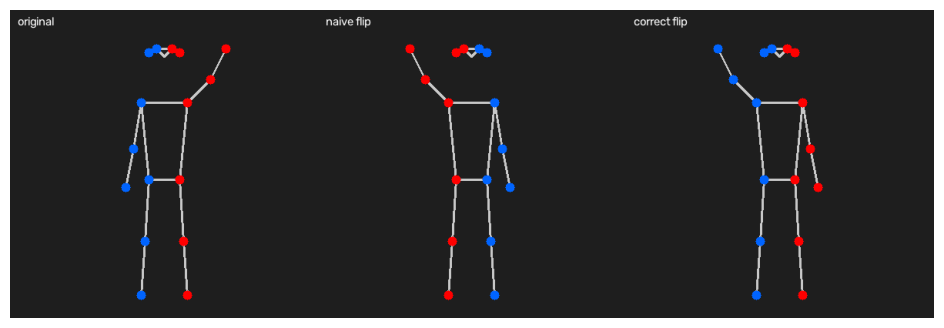

In [7]:
LEFT_INDICES = {left for left, _ in LEFT_RIGHT_PAIRS}
RIGHT_INDICES = {right for _, right in LEFT_RIGHT_PAIRS}


def render(key_points: sv.KeyPoints, canvas: np.ndarray) -> np.ndarray:
    """Draw the skeleton, coloring left-side joints blue and right-side joints red."""
    scene = sv.EdgeAnnotator(color=sv.Color(200, 200, 200), thickness=2).annotate(
        canvas.copy(), key_points
    )

    num_points = key_points.xy.shape[1]
    left_mask = np.array([[i in LEFT_INDICES for i in range(num_points)]])
    right_mask = np.array([[i in RIGHT_INDICES for i in range(num_points)]])

    left_kp = sv.KeyPoints(xy=key_points.xy, class_id=key_points.class_id, visible=left_mask)
    right_kp = sv.KeyPoints(xy=key_points.xy, class_id=key_points.class_id, visible=right_mask)

    scene = sv.VertexAnnotator(color=sv.Color(0, 100, 255), radius=6).annotate(scene, left_kp)
    scene = sv.VertexAnnotator(color=sv.Color(255, 0, 0), radius=6).annotate(scene, right_kp)
    return scene


panels = [
    ("original", key_points),
    ("naive flip", naive_flip),
    ("correct flip", correct_flip),
]
canvas = np.full((IMAGE_HEIGHT, IMAGE_WIDTH, 3), 30, dtype=np.uint8)
images = [render(kp, canvas) for _, kp in panels]
combined = np.concatenate(images, axis=1)
for i, (title, _) in enumerate(panels):
    cv2.putText(
        combined, title, (i * IMAGE_WIDTH + 10, 20),
        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA,
    )

sv.plot_image(combined, size=(12, 4))